## STEP 1 : Import all the Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder,
    LabelEncoder,
    OrdinalEncoder
)

# Feature Selection
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    mutual_info_classif
)

# PCA
from sklearn.decomposition import PCA

# Train Test Split
from sklearn.model_selection import train_test_split

# Gaussian Test
from scipy.stats import shapiro

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## STEP 2  : Load the Dataset

In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 3 : Basic Information about the data

In [ ]:
print(df.shape) #Tells us about the number of rows and columns
print(df.info())  #Tells us about each col datatypes and null values
print(df.describe()) #Tells us about the min, max, mean, etc for each column

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
         survived      pclass         age       sibsp       parc

## STEP 5 : Find Duplicate Values

In [ ]:
print(df.duplicated().sum())
df = df.drop_duplicates()

107


## STEP 4 : Find Missing Values
We have some missing values we need to fix it later on after getting to know about the numerical and categorical columns

In [ ]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64


## STEP 6 : Categories between numerical and categroical columns

In [ ]:
numerical_cols = []
categorical_cols = []

for col in df.columns:

    # Ignore target column if needed
    # if col == 'survived':
    #     continue

    # Check categorical/object/category datatype
    if (
        df[col].dtype == 'object' or
        str(df[col].dtype) == 'category'
    ):
        categorical_cols.append(col)

    else:
        numerical_cols.append(col)

print("numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

numerical Columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone']

Categorical Columns:
['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']


## STEP 7A : Check for Gaussian Distribution

We needed to handle the missing values in the Age and Deck column but as far as I am concerned, Deck should be a categorical column and Age should be a numerical col, And age follows somehow the gaussian distribution so we may apply mean imputer, and in deck as it is a categorical col we should apply mode.

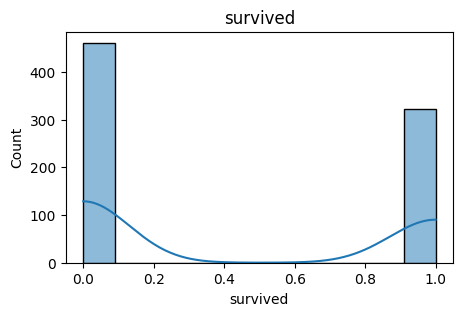

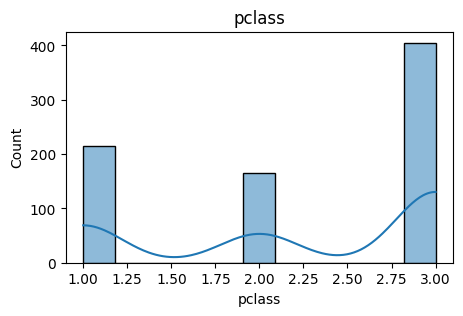

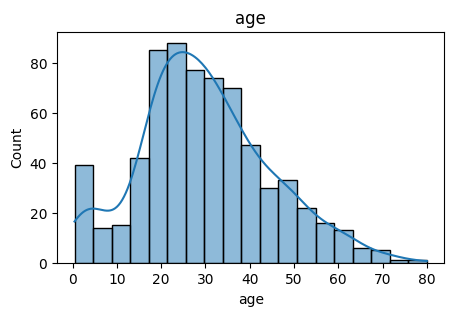

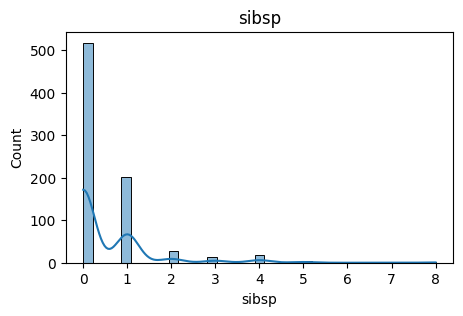

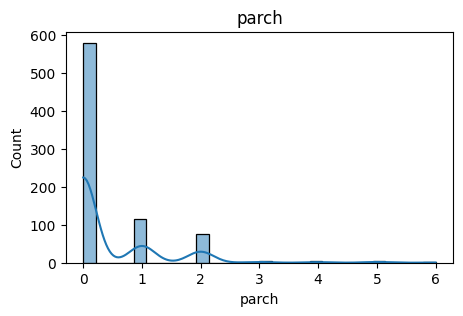

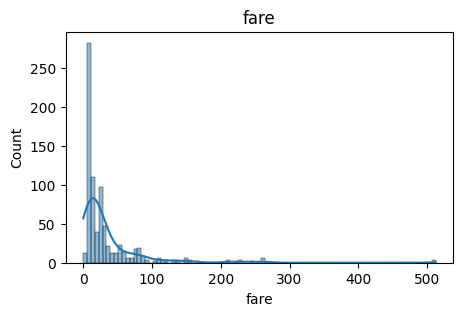

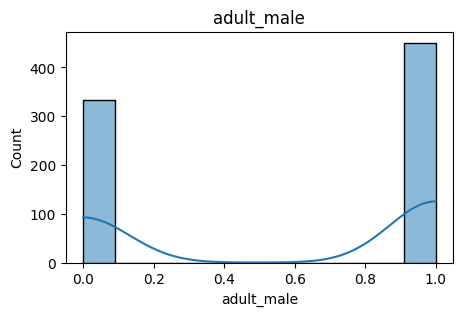

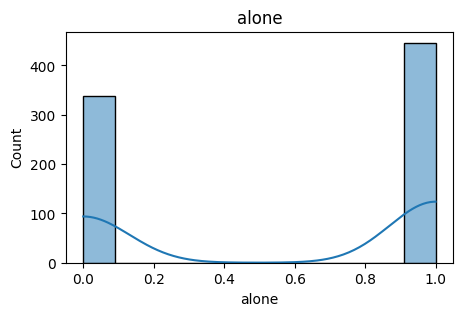

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(5,3))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

## STEP 7B : Check for Gaussian Distribution (Skewness Method)

This Also Suggests Age is Gaussian

In [ ]:
print("\nGaussian Distribution Check\n")

for col in numerical_cols:

    # Skip binary / ordinal columns manually
    if col in ['survived', 'pclass']:
        print(f"{col} --> Skipped (Binary/Ordinal Categorical)")
        continue

    skewness = df[col].skew()

    print(f"{col} --> Skewness = {round(skewness, 3)}")

    # Logic
    if -0.5 <= skewness <= 0.5:
        print("Approximately Gaussian")
        print("Recommended Imputer : Mean\n")

    elif -1 <= skewness < -0.5 or 0.5 < skewness <= 1:
        print("Moderately Skewed")
        print("Recommended Imputer : Median\n")

    else:
        print("Highly Skewed")
        print("Recommended Imputer : Median\n")


Gaussian Distribution Check

survived --> Skipped (Binary/Ordinal Categorical)
pclass --> Skipped (Binary/Ordinal Categorical)
age --> Skewness = 0.367
Approximately Gaussian
Recommended Imputer : Mean

sibsp --> Skewness = 3.055
Highly Skewed
Recommended Imputer : Median

parch --> Skewness = 2.633
Highly Skewed
Recommended Imputer : Median

fare --> Skewness = 4.571
Highly Skewed
Recommended Imputer : Median

adult_male --> Skewness = -0.305
Approximately Gaussian
Recommended Imputer : Mean

alone --> Skewness = -0.279
Approximately Gaussian
Recommended Imputer : Mean



## STEP 7C : Check for Gaussian Distribution (Sheparo Method)

This Suggests none is Gaussian

In [ ]:
for col in numerical_cols:

    stat, p = shapiro(df[col].dropna())

    if p > 0.05:
      print("Gaussian Distribution")
    else:
      print("Not Gaussian")

Not Gaussian
Not Gaussian
Not Gaussian
Not Gaussian
Not Gaussian
Not Gaussian
Not Gaussian
Not Gaussian


## STEP 8 : Handle the missing values

Finally we would handle the Age with Mean Imputer and Deck with Mode

In [ ]:
mean_value = df['age'].mean()
for col in categorical_cols:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

df['age'].fillna(mean_value, inplace=True)

In [ ]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


## STEP 9 : Outliers Detection
New Section
Feature	Best Handling

sibsp	- Keep

parch	- Keep

fare	- Transform

In [ ]:
import pandas as pd
import numpy as np

print("OUTLIER DETECTION USING IQR\n")

for col in df.columns:

    # Skip categorical/object/category columns
    if (
        df[col].dtype == 'object' or
        str(df[col].dtype) == 'category' or
        df[col].dtype == 'bool'
    ):
        continue

    # Skip binary/ordinal categorical features
    if col in ['survived', 'pclass']:
        continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(f"Column : {col}")
    print(f"Skewness : {round(df[col].skew(), 3)}")
    print(f"Lower Bound : {round(lower_bound, 3)}")
    print(f"Upper Bound : {round(upper_bound, 3)}")
    print(f"Outliers : {outliers.shape[0]}")
    print("-" * 50)

OUTLIER DETECTION USING IQR

Column : sibsp
Skewness : 3.055
Lower Bound : -1.5
Upper Bound : 2.5
Outliers : 39
--------------------------------------------------
Column : parch
Skewness : 2.633
Lower Bound : -1.5
Upper Bound : 2.5
Outliers : 15
--------------------------------------------------
Column : fare
Skewness : 4.571
Lower Bound : -31.039
Upper Bound : 73.198
Outliers : 102
--------------------------------------------------


## STEP 10 A : Feature Transformation For Numerical Cols
Here SIBSP and PARCH do not need to be transformed but fare we need to log transform, It became perfectly gaussian after log transform


Skewness After Log Transform :
0.41616155760723034


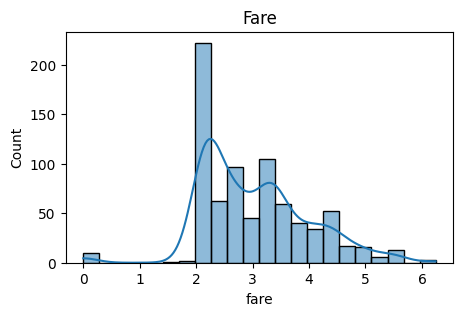

In [ ]:
df['fare'] = np.log1p(df['fare'])
print("Skewness After Log Transform :")
print(df['fare'].skew())

plt.figure(figsize=(5,3))

sns.histplot(df['fare'], kde=True)

plt.title('Fare')

plt.show()


## STEP 10 B : Feature Transformation For categorical Cols

For the Titanic dataset, categorical feature transformation is performed according to the semantic meaning and cardinality of each column. Columns such as `sex`, `embarked`, `deck`, `who`, and `embark_town` are nominal categorical features because no meaningful ordering exists between their categories, so dummy encoding is applied using `drop_first=True` to reduce redundancy and avoid unnecessary extra columns. The `class` column is treated as an ordinal feature since passenger classes have a natural ranking (`Third < Second < First`), therefore Ordinal Encoding is used to preserve that order numerically. The `alive` column is removed because it directly leaks the target variable information (`survived`) and would lead to incorrect model learning.


In [ ]:
print(categorical_cols)
print(df.head())

['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']
   survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
0         0       3    male  22.0      1      0  2.110213        S  Third   
1         1       1  female  38.0      1      0  4.280593        C  First   
2         1       3  female  26.0      0      0  2.188856        S  Third   
3         1       1  female  35.0      1      0  3.990834        S  First   
4         0       3    male  35.0      0      0  2.202765        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True    C  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False    C  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True    C  Southampton    no   True  


In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# -----------------------------------
# DROP LEAKAGE COLUMN
# -----------------------------------

df.drop(columns=['alive'], inplace=True)

# -----------------------------------
# ORDINAL ENCODING
# -----------------------------------

encoder = OrdinalEncoder(
    categories=[['Third', 'Second', 'First']]
)

df['class'] = encoder.fit_transform(df[['class']])

# -----------------------------------
# DUMMY ENCODING
# -----------------------------------

df = pd.get_dummies(
    df,
    columns=[
        'sex',
        'embarked',
        'deck',
        'who',
        'embark_town'
    ],
    drop_first=True
)

# -----------------------------------
# CONVERT BOOL TO INT
# -----------------------------------

bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    df[col] = df[col].astype(int)

# -----------------------------------
# FINAL OUTPUT
# -----------------------------------

print(df.head())

print("\nColumns:\n")
print(df.columns)

   survived  pclass   age  sibsp  parch      fare  class  adult_male  alone  \
0         0       3  22.0      1      0  2.110213    0.0           1      0   
1         1       1  38.0      1      0  4.280593    2.0           0      0   
2         1       3  26.0      0      0  2.188856    0.0           0      1   
3         1       1  35.0      1      0  3.990834    2.0           0      0   
4         0       3  35.0      0      0  2.202765    0.0           1      1   

   sex_male  ...  deck_B  deck_C  deck_D  deck_E  deck_F  deck_G  who_man  \
0         1  ...       0       1       0       0       0       0        1   
1         0  ...       0       1       0       0       0       0        0   
2         0  ...       0       1       0       0       0       0        0   
3         0  ...       0       1       0       0       0       0        0   
4         1  ...       0       1       0       0       0       0        1   

   who_woman  embark_town_Queenstown  embark_town_Southampton 

## STEP 11 : Feature Scaling
1. If gaussian - Standardisation
2. If outliers - Robust Scaling
3. If non-gaussian - Min-Max Scaling

age, fare are gassian
sbsp and posh contains outliers

In [ ]:
# Convert age safely into numeric

df['age'] = pd.to_numeric(
    df['age'],
    errors='coerce'
)

# Check datatype
print(df[['age', 'fare']].dtypes)

age     float64
fare    float64
dtype: object


In [ ]:
standard_scaler = StandardScaler()

gaussian_cols = ['age', 'fare']

df[gaussian_cols] = standard_scaler.fit_transform(
    df[gaussian_cols]
)

print(df.head())

   survived  pclass       age  sibsp  parch      fare  class  adult_male  \
0         0       3 -0.533581      1      0 -0.965846    0.0           1   
1         1       1  0.551298      1      0  1.283765    2.0           0   
2         1       3 -0.262361      0      0 -0.884332    0.0           0   
3         1       1  0.347883      1      0  0.983428    2.0           0   
4         0       3  0.347883      0      0 -0.869916    0.0           1   

   alone  sex_male  ...  deck_B  deck_C  deck_D  deck_E  deck_F  deck_G  \
0      0         1  ...       0       1       0       0       0       0   
1      0         0  ...       0       1       0       0       0       0   
2      1         0  ...       0       1       0       0       0       0   
3      0         0  ...       0       1       0       0       0       0   
4      1         1  ...       0       1       0       0       0       0   

   who_man  who_woman  embark_town_Queenstown  embark_town_Southampton  
0        1         

In [ ]:
robust_scaler = RobustScaler()

robust_cols = [
    'sibsp',
    'parch'
]

# Apply Robust Scaling
df[robust_cols] = robust_scaler.fit_transform(
    df[robust_cols]
)

# -----------------------------------
# CHECK OUTPUT
# -----------------------------------

print(df[robust_cols].head())

   sibsp  parch
0    1.0    0.0
1    1.0    0.0
2    0.0    0.0
3    1.0    0.0
4    0.0    0.0


# STEP 12 : Feature Selection

Through 3 menthods -
1. Correlation
2. Chi square
3. Mutual Informations


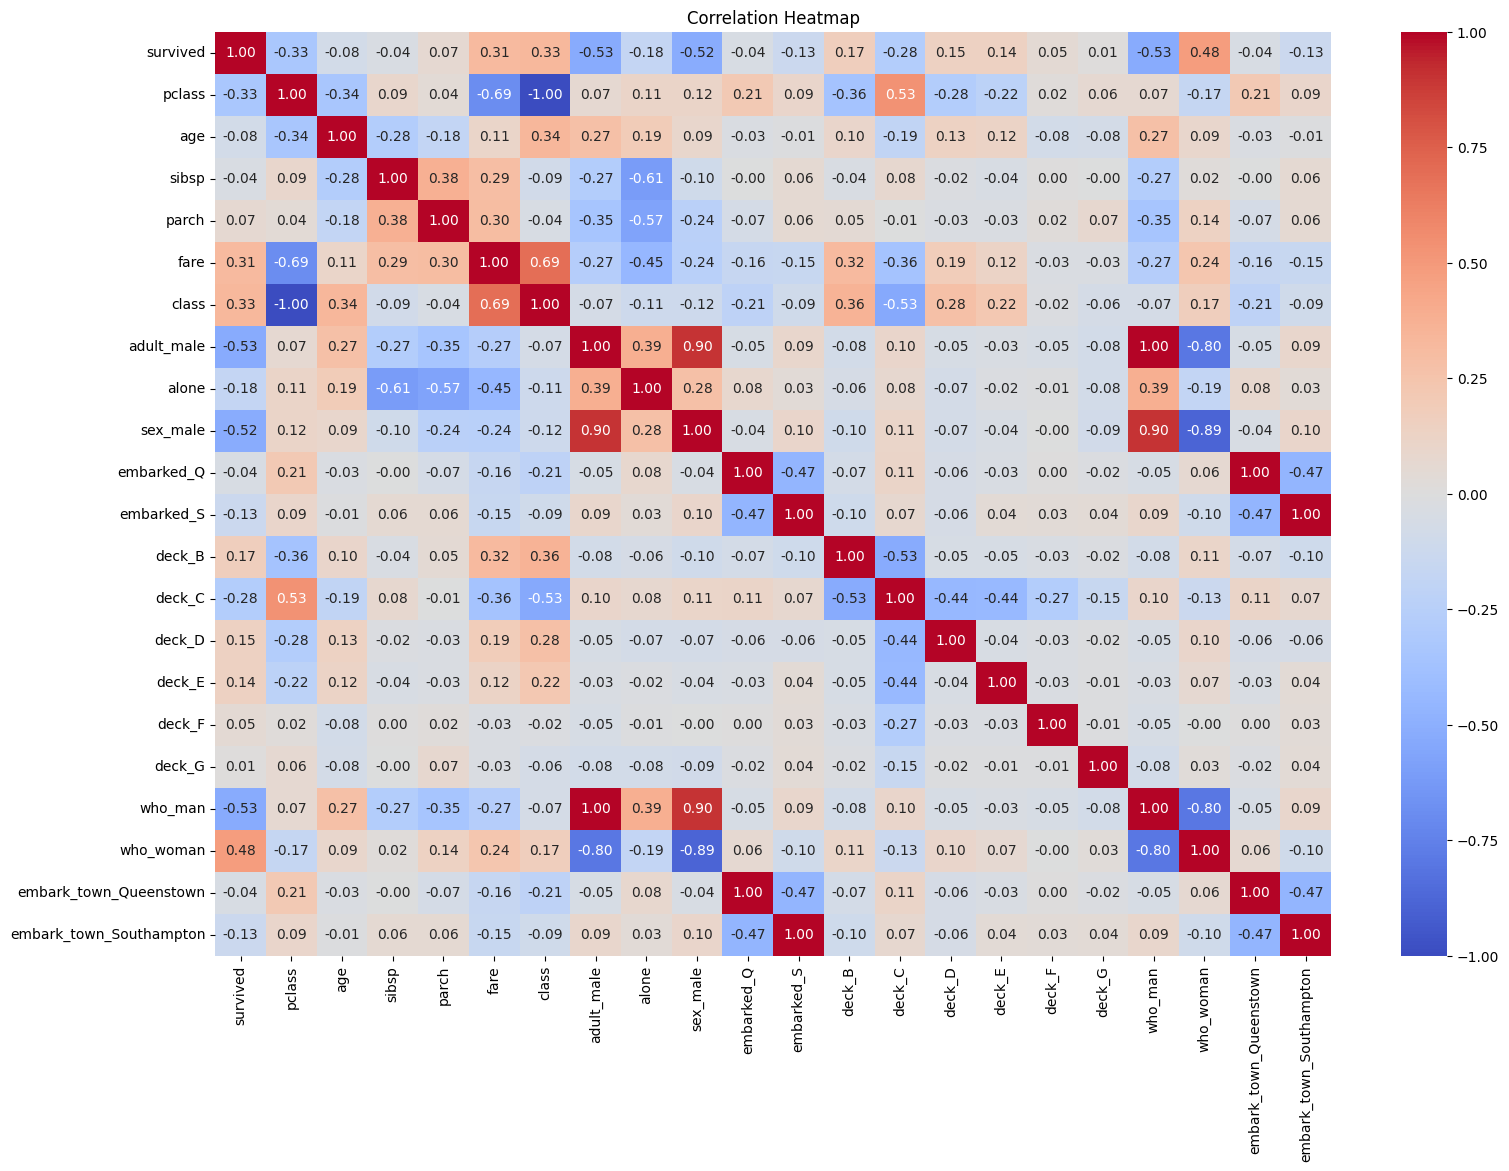

Highly Correlated Columns:
['class', 'sex_male', 'who_man', 'who_woman', 'embark_town_Queenstown', 'embark_town_Southampton']

Chi-Square Scores:

                    Feature  Chi2 Score       P-Value
18                who_woman  123.309366  1.193164e-28
6                adult_male   93.011564  5.198969e-22
17                  who_man   93.011564  5.198969e-22
5                     class   83.754560  5.601770e-20
8                  sex_male   77.943949  1.060063e-18
0                    pclass   50.939953  9.523524e-13
4                      fare   24.382676  7.897573e-07
11                   deck_B   20.321488  6.546128e-06
13                   deck_D   16.268773  5.496231e-05
14                   deck_E   15.091704  1.024124e-04
12                   deck_C   10.870435  9.771156e-04
7                     alone   10.540852  1.167646e-03
3                     parch    6.519749  1.066831e-02
20  embark_town_Southampton    3.452453  6.315798e-02
10               embarked_S    3.452453  6.

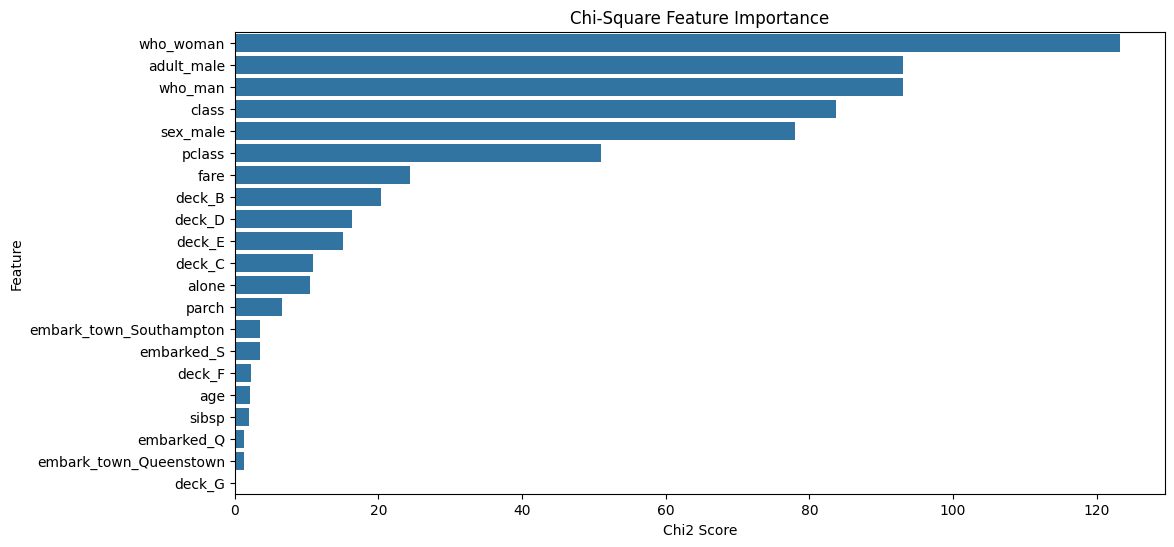


Mutual Information Scores:

                    Feature  Mutual Info Score
6                adult_male           0.135651
17                  who_man           0.127766
18                who_woman           0.127297
4                      fare           0.101874
8                  sex_male           0.100397
0                    pclass           0.081048
3                     parch           0.038017
2                     sibsp           0.029166
5                     class           0.028682
12                   deck_C           0.027740
9                embarked_Q           0.019592
13                   deck_D           0.017638
7                     alone           0.014781
15                   deck_F           0.007570
19   embark_town_Queenstown           0.005188
11                   deck_B           0.004161
16                   deck_G           0.001813
1                       age           0.000000
10               embarked_S           0.000000
14                   deck_E    

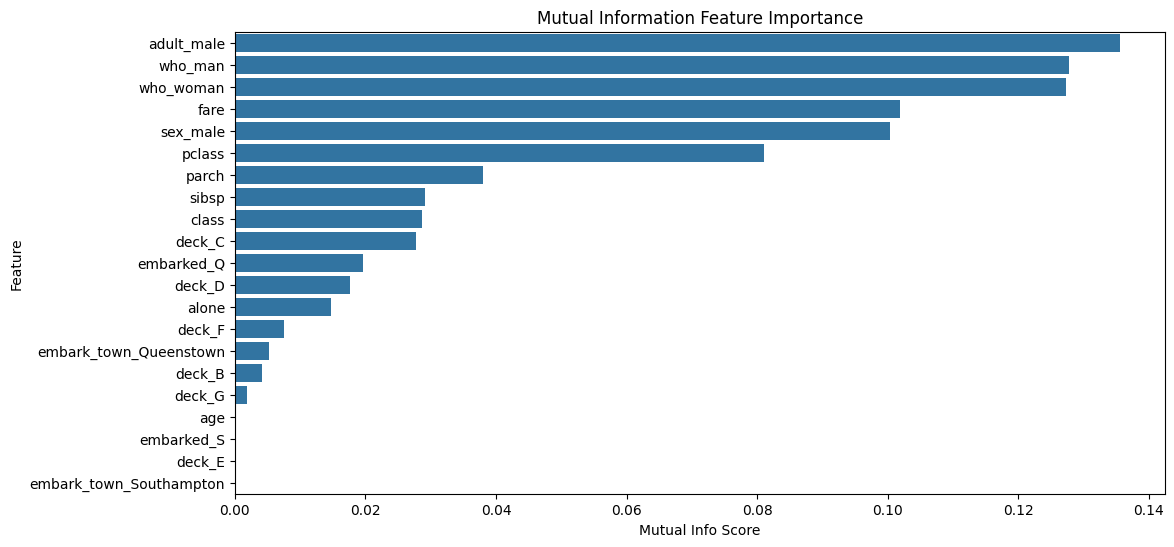

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import (
    chi2,
    mutual_info_classif
)

# =========================================================
# HANDLE MISSING VALUES BEFORE FEATURE SELECTION
# =========================================================

df['age'] = df['age'].fillna(df['age'].median())

# =========================================================
# FEATURES & TARGET
# =========================================================

X = df.drop(columns=['survived'])
y = df['survived']

# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(18, 12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# =========================================================
# HIGHLY CORRELATED FEATURES
# =========================================================

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.85

high_corr_cols = [
    column for column in upper.columns
    if any(upper[column] > threshold)
]

print("Highly Correlated Columns:")
print(high_corr_cols)

# =========================================================
# CHI-SQUARE TEST
# =========================================================

# Chi2 requires non-negative values
X_chi = X.copy()

# Convert everything positive
X_chi = X_chi - X_chi.min()

chi_scores = chi2(X_chi, y)

chi_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': chi_scores[0],
    'P-Value': chi_scores[1]
})

chi_df = chi_df.sort_values(
    by='Chi2 Score',
    ascending=False
)

print("\nChi-Square Scores:\n")
print(chi_df)

# =========================================================
# CHI-SQUARE VISUALIZATION
# =========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Chi2 Score',
    y='Feature',
    data=chi_df
)

plt.title("Chi-Square Feature Importance")
plt.show()

# =========================================================
# MUTUAL INFORMATION
# =========================================================

mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Info Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='Mutual Info Score',
    ascending=False
)

print("\nMutual Information Scores:\n")
print(mi_df)

# =========================================================
# MUTUAL INFO VISUALIZATION
# =========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Mutual Info Score',
    y='Feature',
    data=mi_df
)

plt.title("Mutual Information Feature Importance")
plt.show()

In [ ]:
# -----------------------------------
# REMOVE HIGHLY CORRELATED FEATURES
# -----------------------------------

high_corr_cols = [
    'class',
    'sex_male',
    'who_man',
    'who_woman',
    'embark_town_Queenstown',
    'embark_town_Southampton'
]

df.drop(columns=high_corr_cols, inplace=True)

# -----------------------------------
# CHECK FINAL COLUMNS
# -----------------------------------

print(df.columns)

print("\nUpdated Shape :", df.shape)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'alone', 'embarked_Q', 'embarked_S', 'deck_B', 'deck_C', 'deck_D',
       'deck_E', 'deck_F', 'deck_G'],
      dtype='object')

Updated Shape : (784, 16)


In [ ]:
df.head()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,embarked_Q,embarked_S,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G
0,0,3,-0.533581,1.0,0.0,-0.965846,1,0,0,1,0,1,0,0,0,0
1,1,1,0.551298,1.0,0.0,1.283765,0,0,0,0,0,1,0,0,0,0
2,1,3,-0.262361,0.0,0.0,-0.884332,0,1,0,1,0,1,0,0,0,0
3,1,1,0.347883,1.0,0.0,0.983428,0,0,0,1,0,1,0,0,0,0
4,0,3,0.347883,0.0,0.0,-0.869916,1,1,0,1,0,1,0,0,0,0
